# Part 2: Computer Vision Problem Formulation and CNN Prototype
### Dataset: Dental Image Classification

In [2]:
import subprocess
subprocess.run(["pip", "install", "opencv-python"])

CompletedProcess(args=['pip', 'install', 'opencv-python'], returncode=0)

In [3]:
# Importing all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

print("All libraries imported successfully")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
TensorFlow version: 2.21.0


## Task 1: Problem Identification

In [4]:
# This dataset contains dental images divided into 4 categories
# dent, normal, scratch, stain

# This is an Image Classification problem because:
# - Each image belongs to exactly one category
# - The goal is to assign a label to each image
# - There are no bounding boxes or pixel-level annotations

print("Problem Type: Image Classification")
print("Dataset: Dental Condition Images")
print("Number of Classes: 4")
print("Classes: dent, normal, scratch, stain")
print("\nWhy Image Classification")
print("Each image shows one dental condition and we need to")
print("classify it into one of the 4 categories.")
print("There is no need for object detection or segmentation")
print("as the entire image represents a single condition.")

Problem Type: Image Classification
Dataset: Dental Condition Images
Number of Classes: 4
Classes: dent, normal, scratch, stain

Why Image Classification
Each image shows one dental condition and we need to
classify it into one of the 4 categories.
There is no need for object detection or segmentation
as the entire image represents a single condition.


## Task 2: Dataset Exploration

In [5]:
# Path to images folder
images_path = r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-2-cnn-computer-vision\images'

# Get class names from folder names
classes = ['dent', 'normal', 'scratch', 'stain']

# Count images in each class
print("Dataset Summary:")
print("-" * 30)
total = 0
for cls in classes:
    folder = os.path.join(images_path, cls)
    count = len([f for f in os.listdir(folder) if f.endswith('.png') or f.endswith('.jpg')])
    print(f"Class '{cls}': {count} images")
    total += count

print("-" * 30)
print(f"Total images: {total}")
print(f"Number of classes: {len(classes)}")
print("\nDataset is perfectly balanced - each class has equal images")

Dataset Summary:
------------------------------
Class 'dent': 120 images
Class 'normal': 120 images
Class 'scratch': 120 images
Class 'stain': 120 images
------------------------------
Total images: 480
Number of classes: 4

Dataset is perfectly balanced - each class has equal images


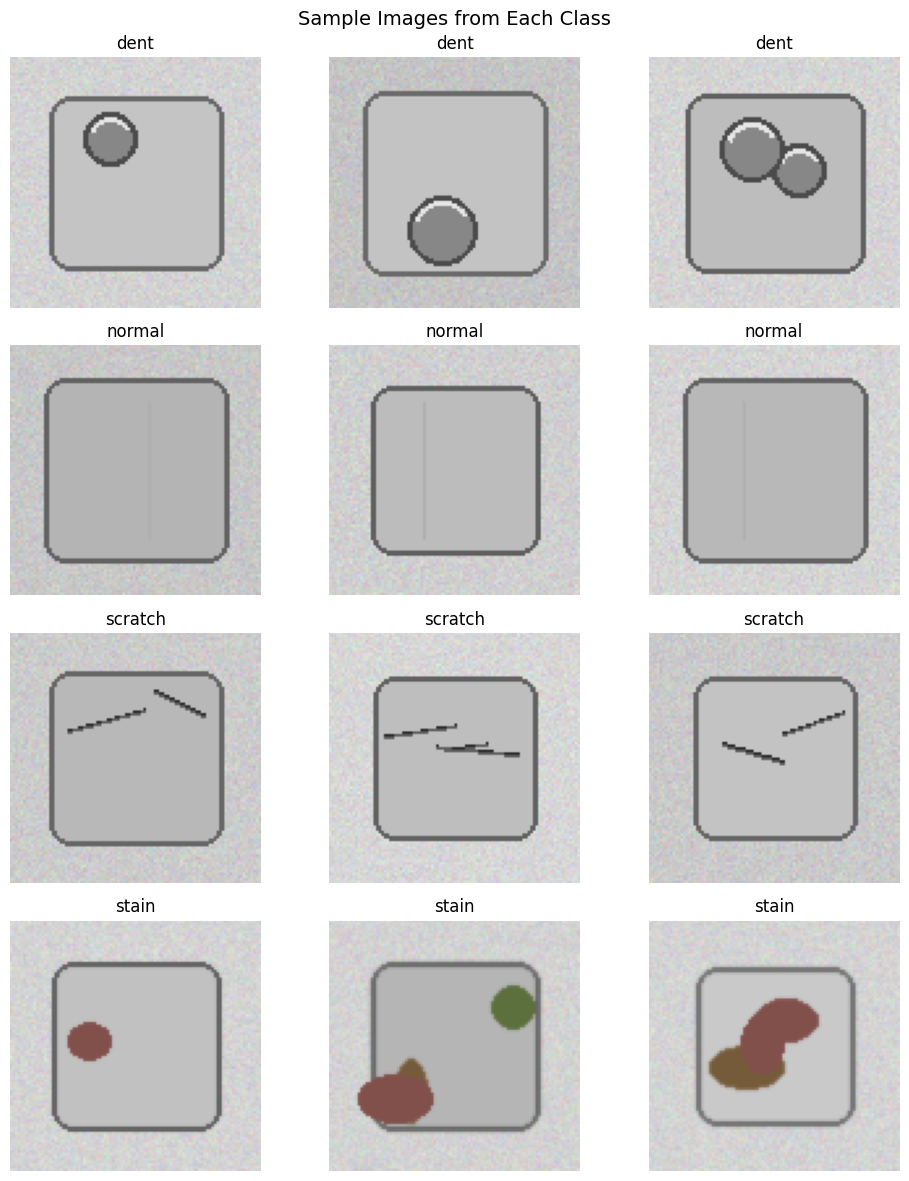

Sample images saved


In [6]:
# Show sample images from each class
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle('Sample Images from Each Class', fontsize=14)

for i, cls in enumerate(classes):
    folder = os.path.join(images_path, cls)
    images = os.listdir(folder)[:3]  # Get first 3 images
    
    for j, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i][j].imshow(img)
        axes[i][j].set_title(f'{cls}')
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-2-cnn-computer-vision\results\sample_images.png')
plt.show()
print("Sample images saved")

In [7]:
# Check image dimensions
sample_img_path = os.path.join(images_path, 'dent', os.listdir(os.path.join(images_path, 'dent'))[0])
sample_img = cv2.imread(sample_img_path)

print("Sample image shape:", sample_img.shape)
print(f"Height: {sample_img.shape[0]} pixels")
print(f"Width: {sample_img.shape[1]} pixels")
print(f"Channels: {sample_img.shape[2]} (RGB)")
print("\nAll images will be resized to 64x64 for model training")

Sample image shape: (96, 96, 3)
Height: 96 pixels
Width: 96 pixels
Channels: 3 (RGB)

All images will be resized to 64x64 for model training


## Task 3: Image Preprocessing

In [8]:
# Loading and preprocessing all images
IMG_SIZE = 64
data = []
labels = []

for cls_idx, cls in enumerate(classes):
    folder = os.path.join(images_path, cls)
    for img_name in os.listdir(folder):
        if img_name.endswith('.png') or img_name.endswith('.jpg'):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)
            labels.append(cls_idx)

# Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

# Normalize pixel values (0-255 to 0-1)
data = data / 255.0

print("Total images loaded:", len(data))
print("Image shape after resize:", data[0].shape)
print("Labels shape:", labels.shape)
print("\nPixel values normalized to range 0-1")

Total images loaded: 480
Image shape after resize: (64, 64, 3)
Labels shape: (480,)

Pixel values normalized to range 0-1


In [9]:
# Convert labels to categorical (one-hot encoding)
labels_cat = to_categorical(labels, num_classes=4)

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    data, labels_cat, test_size=0.2, random_state=42, stratify=labels
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nClass distribution in training set:")
train_labels = np.argmax(y_train, axis=1)
for i, cls in enumerate(classes):
    print(f"  {cls}: {np.sum(train_labels == i)} images")

Training set size: (384, 64, 64, 3)
Testing set size: (96, 64, 64, 3)

Class distribution in training set:
  dent: 96 images
  normal: 96 images
  scratch: 96 images
  stain: 96 images


## Task 4: CNN Model Creation

In [10]:
# Building the CNN model
model = Sequential([
    Input(shape=(64, 64, 3)),
    
    # First convolution block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Second convolution block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Third convolution block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Flatten and dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Task 5: Model Training and Evaluation

In [11]:
# Training the CNN model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nModel training complete")

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - accuracy: 0.2474 - loss: 1.3985 - val_accuracy: 0.2500 - val_loss: 1.3702
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.3073 - loss: 1.3147 - val_accuracy: 0.5729 - val_loss: 1.1778
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5339 - loss: 1.0294 - val_accuracy: 0.6354 - val_loss: 0.8330
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.6797 - loss: 0.7767 - val_accuracy: 0.7292 - val_loss: 0.6221
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.7708 - loss: 0.5712 - val_accuracy: 0.8854 - val_loss: 0.3432
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 394ms/step - accuracy: 0.8906 - loss: 0.3829 - val_accuracy: 0.9375 - val_loss: 0.1937
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.9167 - loss: 0.2413 - val_accuracy: 0.9167 - val_loss: 0.2442
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9323 - loss: 0.1974 - val_accuracy: 0

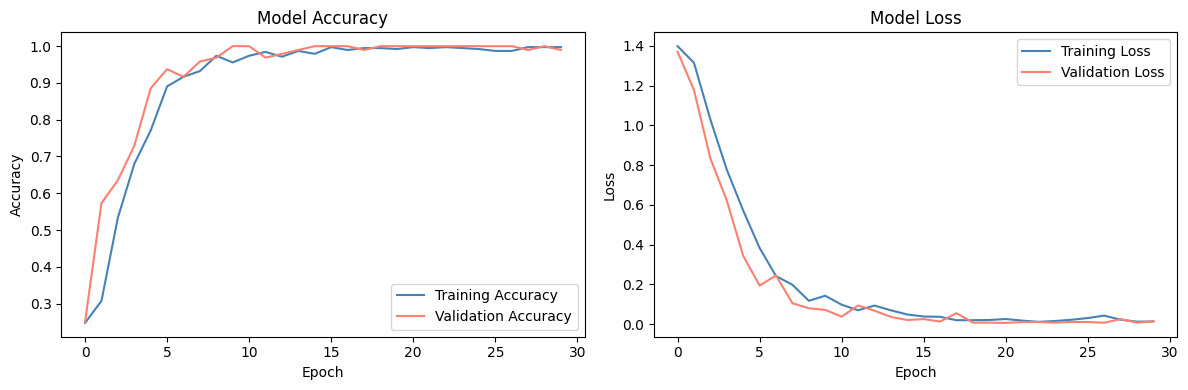

Training curves saved


In [12]:
# Plotting training and validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='salmon')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='salmon')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-2-cnn-computer-vision\results\accuracy_loss_curves.png')
plt.show()
print("Training curves saved")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step
Classification Report:
              precision    recall  f1-score   support

        dent       0.96      1.00      0.98        24
      normal       1.00      1.00      1.00        24
     scratch       1.00      0.96      0.98        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.99        96
   macro avg       0.99      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96



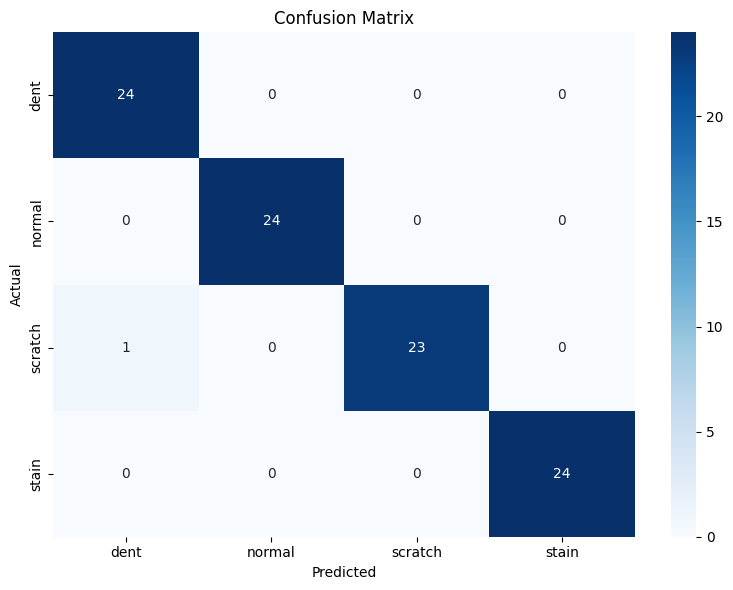

Confusion matrix saved


In [13]:
# Getting predictions on test data
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-2-cnn-computer-vision\results\confusion_matrix.png')
plt.show()
print("Confusion matrix saved")

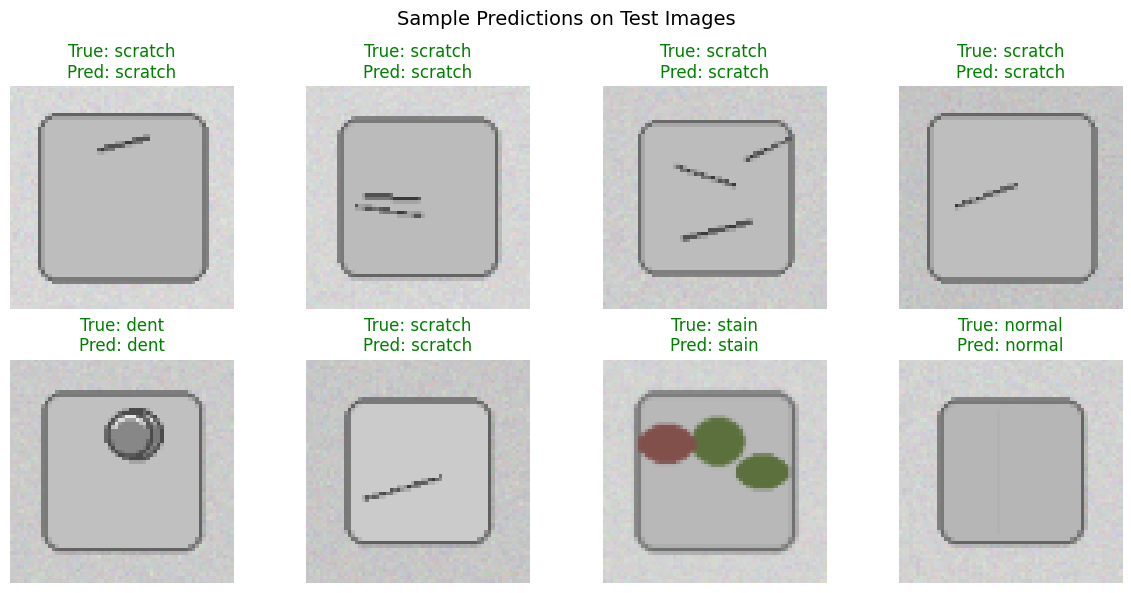

Sample predictions saved


In [14]:
# Show sample predictions on test images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Predictions on Test Images', fontsize=14)

for i, ax in enumerate(axes.flatten()):
    img = X_test[i]
    true_label = classes[y_true[i]]
    pred_label = classes[y_pred[i]]
    
    ax.imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-2-cnn-computer-vision\sample_predictions\prediction_outputs.png')
plt.show()
print("Sample predictions saved")